In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
barrs = [5,7,9,11,13]

Q_PMF = np.loadtxt('../../Data/protG/PMF/pmf_Q.dat',skiprows=1)
Q_PMF[:,1] -= np.min(Q_PMF[:,1])
E_PMF = np.loadtxt('../../Data/protG/PMF/pmf_E.dat',skiprows=1)
E_PMF[:,1] -= np.min(E_PMF[:,1])

In [3]:
runs = [f'run_{i+1}' for i in range(100)]
Q = np.linspace(0,1,1000)
kbt = 312*0.008314

def gaussian(x,mu,sigma,h):
    return h*np.exp(-0.5*(x-mu)**2/(sigma*sigma))

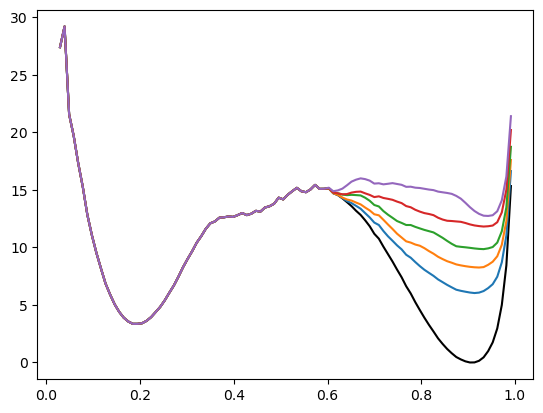

In [4]:
Vs_Q = []
plt.plot(Q_PMF[:,0],Q_PMF[:,1],color='k')

for i, barr in enumerate(barrs):
    
    Vs_Q.append(np.zeros_like(Q_PMF[:,0]))
    
    for run in runs:
        f = open(f'../../Data/protG/Q_frac_native_contacts_opes/qruns_barr{barr}/{run}/STATE','r')
        lines = f.readlines()
        biasf = np.float64(lines[2].split()[-1])
        eps = np.float64(lines[3].split()[-1])
        Z = np.float64(lines[6].split()[-1])
        C = np.float64(lines[7].split()[-1])
        P = np.zeros_like(Q_PMF[:,0])
        
        states = np.loadtxt(f'../../Data/protG/Q_frac_native_contacts_opes/qruns_barr{barr}/{run}/STATE',skiprows=10)
        if type(states[0]) == np.float64:
            P += gaussian(Q_PMF[:,0],states[1],states[2],states[3])
        else:
            for line in states:
                P += gaussian(Q_PMF[:,0],line[1],line[2],line[3])

        P /= C
        Vs_Q[-1] += kbt*(1-1/biasf)*np.log(P/Z + eps) + barr

    Vs_Q[-1] /= 100
    plt.plot(Q_PMF[:,0],Vs_Q[-1]+Q_PMF[:,1],label=f'Barr {barr}')

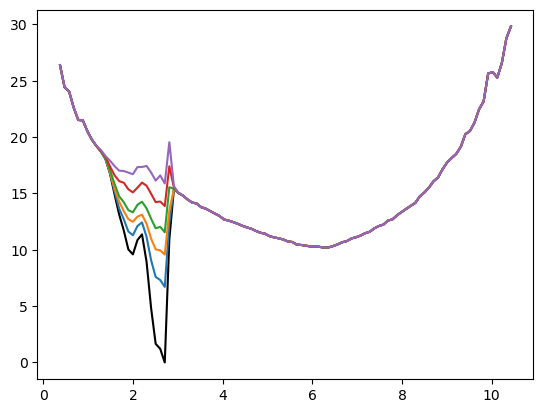

In [5]:
Vs_E = []
plt.plot(E_PMF[:,0],E_PMF[:,1],color='k')

for i, barr in enumerate([5,7,9,11,13]):
    
    Vs_E.append(np.zeros_like(E_PMF[:,0]))
    
    for run in runs:
        f = open(f'../../Data/protG/E_end_end_distance_opes/eruns_barr{barr}/{run}/STATE','r')
        lines = f.readlines()
        biasf = np.float64(lines[2].split()[-1])
        eps = np.float64(lines[3].split()[-1])
        Z = np.float64(lines[6].split()[-1])
        C = np.float64(lines[7].split()[-1])
        P = np.zeros_like(E_PMF[:,0])
        
        states = np.loadtxt(f'../../Data/protG/E_end_end_distance_opes/eruns_barr{barr}/{run}/STATE',skiprows=10)
        if type(states[0]) == np.float64:
            P += gaussian(E_PMF[:,0],states[1],states[2],states[3])
        else:
            for line in states:
                P += gaussian(E_PMF[:,0],line[1],line[2],line[3])

        P /= C
        Vs_E[-1] += kbt*(1-1/biasf)*np.log(P/Z + eps) + barr

    Vs_E[-1] /= 100
    plt.plot(E_PMF[:,0],Vs_E[-1]+E_PMF[:,1],label=f'Barr {barr}')

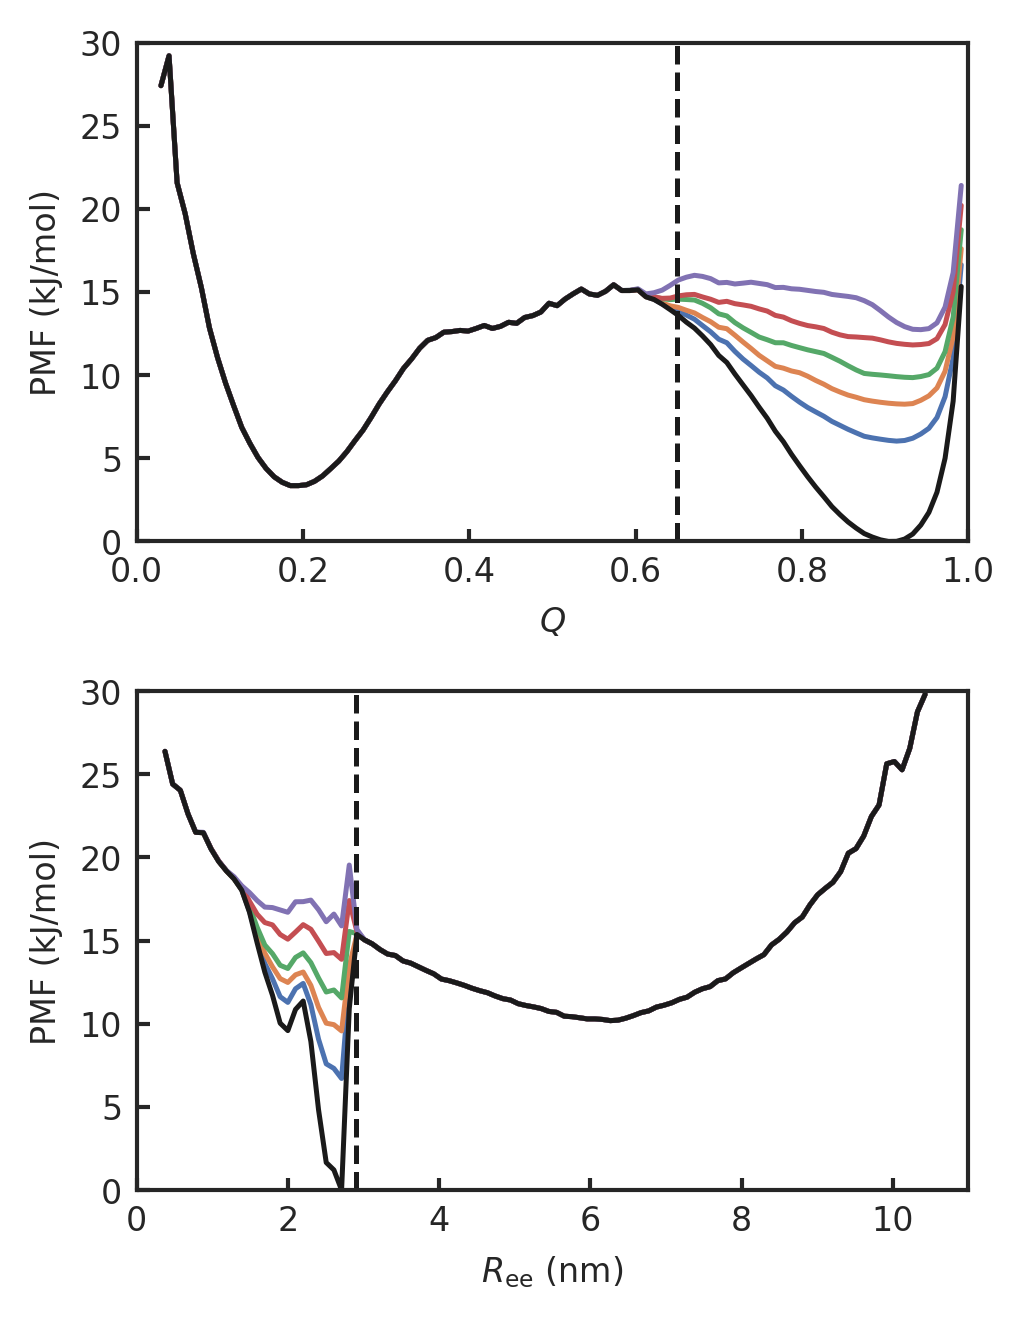

In [6]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

fig, axs = plt.subplots(2,1,figsize=(3.3,4.5),dpi=300,sharey=True,sharex=False)
fig.subplots_adjust(wspace=0.2,hspace=0.3,bottom=0.1,top=0.95,left=0.13,right=0.97)

for i, barr in enumerate([5,7,9,11,13]):
    axs[0].plot(Q_PMF[:,0],Vs_Q[i]+Q_PMF[:,1],label=f'Barr {barr}',color=f'C{i}')
    axs[1].plot(E_PMF[:,0],Vs_E[i]+E_PMF[:,1],label=f'Barr {barr}',color=f'C{i}')

axs[0].axvline(0.65,linestyle='--',color='k')
axs[1].axvline(2.9,linestyle='--',color='k')

axs[0].plot(Q_PMF[:,0],Q_PMF[:,1],color='k')
axs[1].plot(E_PMF[:,0],E_PMF[:,1],color='k')

axs[0].set_ylabel('PMF (kJ/mol)')
axs[1].set_ylabel('PMF (kJ/mol)')
axs[0].set_xlabel(r'$Q$')
axs[1].set_xlabel(r'$R_\mathrm{ee}$ (nm)')
axs[0].set_xlim((0,1))
axs[1].set_xlim((0,11))
axs[0].set_ylim((0,30))

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

plt.savefig("EATRf_Fig2.pdf",format='pdf')